Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


Downloading the Dataset

In [ ]:
CSV_URL = "https://ourworldindata.org/grapher/life-expectancy-un-vs-gdp-per-capita-wb.csv?v=1&csvType=full&useColumnShortNames=true"
print("Downloading the dataset using the URL")
response = requests.get(CSV_URL)
if response.status_code == 200:
    raw_df = pd.read_csv(io.StringIO(response.text))
    print(f"The Dataset has been downloaded successfully!! Shape: {raw_df.shape}")
else:
    print("Could not download, please proceed manually:")


# Preview the raw data
print("\nFirst 5 rows of raw data:")
print(raw_df.head())

print("\n Last 5 rows of raw data:")
print(raw_df.tail())

print("\n Column names:")
print(raw_df.columns.tolist())

The Dataset has been downloaded successfully!! Shape: (19195, 7)

First 5 rows of raw data:
        entity code  year  life_expectancy__sex_all__age_0__variant_estimates  \
0  Afghanistan  AFG  1950                                             28.156    
1  Afghanistan  AFG  1951                                             28.584    
2  Afghanistan  AFG  1952                                             29.014    
3  Afghanistan  AFG  1953                                             29.452    
4  Afghanistan  AFG  1954                                             29.698    

   ny_gdp_pcap_pp_kd  population_historical owid_region  
0                NaN              7776180.0        Asia  
1                NaN              7879343.0        Asia  
2                NaN              7987784.0        Asia  
3                NaN              8096703.0        Asia  
4                NaN              8207954.0        Asia  

 Last 5 rows of raw data:
         entity code  year  \
19190  Zimbabwe 

Explore the data

In [ ]:
print("DATASET OVERVIEW")

print(f"\nShape: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")
print(f"\nData Types:\n{raw_df.dtypes}")
print(f"\nMissing Values per Column:\n{raw_df.isnull().sum()}")
print(f"\nBasic Statistics:\n{raw_df.describe()}")

DATASET OVERVIEW

Shape: 19195 rows × 7 columns

Data Types:
entity                                                 object
code                                                   object
year                                                    int64
life_expectancy__sex_all__age_0__variant_estimates    float64
ny_gdp_pcap_pp_kd                                     float64
population_historical                                 float64
owid_region                                            object
dtype: object

Missing Values per Column:
entity                                                    0
code                                                    370
year                                                      0
life_expectancy__sex_all__age_0__variant_estimates      473
ny_gdp_pcap_pp_kd                                     11955
population_historical                                   615
owid_region                                            1469
dtype: int64

Basic Statistics:
           

Data Preprocessing

In [ ]:
# Renaming the  columns
print("Raw columns:", raw_df.columns.tolist())


col_map = {}
for col in raw_df.columns:
    col_lower = col.lower()
    if 'life' in col_lower or 'expectancy' in col_lower:
        col_map[col] = 'life_expectancy'
    elif 'gdp' in col_lower or 'income' in col_lower:
        col_map[col] = 'gdp_per_capita'
    elif 'entity' in col_lower or 'country' in col_lower:
        col_map[col] = 'country'
    elif 'year' in col_lower:
        col_map[col] = 'year'
    elif 'code' in col_lower:
        col_map[col] = 'code'

df = raw_df.rename(columns=col_map).copy()
print("\n The Columns have been renamed:", df.columns.tolist())


#  Selecting the columns we need
needed = ['country', 'year', 'gdp_per_capita', 'life_expectancy']
df = df[[c for c in needed if c in df.columns]]
print(f"\n The Selected columns are: {df.columns.tolist()}")


# Filter to the most recent complete year with data for both gdp and life expectancy
df_clean = df.dropna(subset=['gdp_per_capita', 'life_expectancy'])
latest_year = df_clean['year'].max()
df_year = df_clean[df_clean['year'] == latest_year].copy()

print(f"\nFiltered to most recent year with data: {latest_year}")
print(f" Countries in this year: {len(df_year)}")


# Removing non-country aggregates (World Bank includes regions)
if 'code' in df_year.columns:
    df_year = df_year[df_year['code'].notna() & (df_year['code'] != '')]
    print(f"   Countries after removing aggregates: {len(df_year)}")


# Removing outliers using IQR method
def remove_outliers_iqr(dataframe, column, factor=3.0):
    """Remove extreme outliers beyond factor*IQR from Q1/Q3."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

before = len(df_year)
df_year = remove_outliers_iqr(df_year, 'gdp_per_capita')
df_year = remove_outliers_iqr(df_year, 'life_expectancy')
after = len(df_year)
print(f"\n Outlier removal: {before - after} rows removed, {after} countries remain.")


#Applying log transformation to GDP per capita

# Log transformation makes the relationship with life expectancy
# much more linear
df_year['log_gdp_per_capita'] = np.log(df_year['gdp_per_capita'])

print("\nLog transformation applied to GDP per capita.")
print(f"\nFinal dataset shape: {df_year.shape}")
print(df_year[['country', 'year', 'gdp_per_capita', 'log_gdp_per_capita', 'life_expectancy']].head(10))

Raw columns: ['entity', 'code', 'year', 'life_expectancy__sex_all__age_0__variant_estimates', 'ny_gdp_pcap_pp_kd', 'population_historical', 'owid_region']

 The Columns have been renamed: ['country', 'code', 'year', 'life_expectancy', 'gdp_per_capita', 'population_historical', 'owid_region']

 The Selected columns are: ['country', 'year', 'gdp_per_capita', 'life_expectancy']

Filtered to most recent year with data: 2023
 Countries in this year: 202

 Outlier removal: 0 rows removed, 202 countries remain.

Log transformation applied to GDP per capita.

Final dataset shape: (202, 5)
                  country  year  gdp_per_capita  log_gdp_per_capita  \
73            Afghanistan  2023       1983.8126            7.592776   
221               Albania  2023      20481.0350            9.927255   
296               Algeria  2023      15159.3240            9.626371   
445               Andorra  2023      64631.2970           11.076454   
520                Angola  2023       8788.2610          

Exploratory Data Analysis

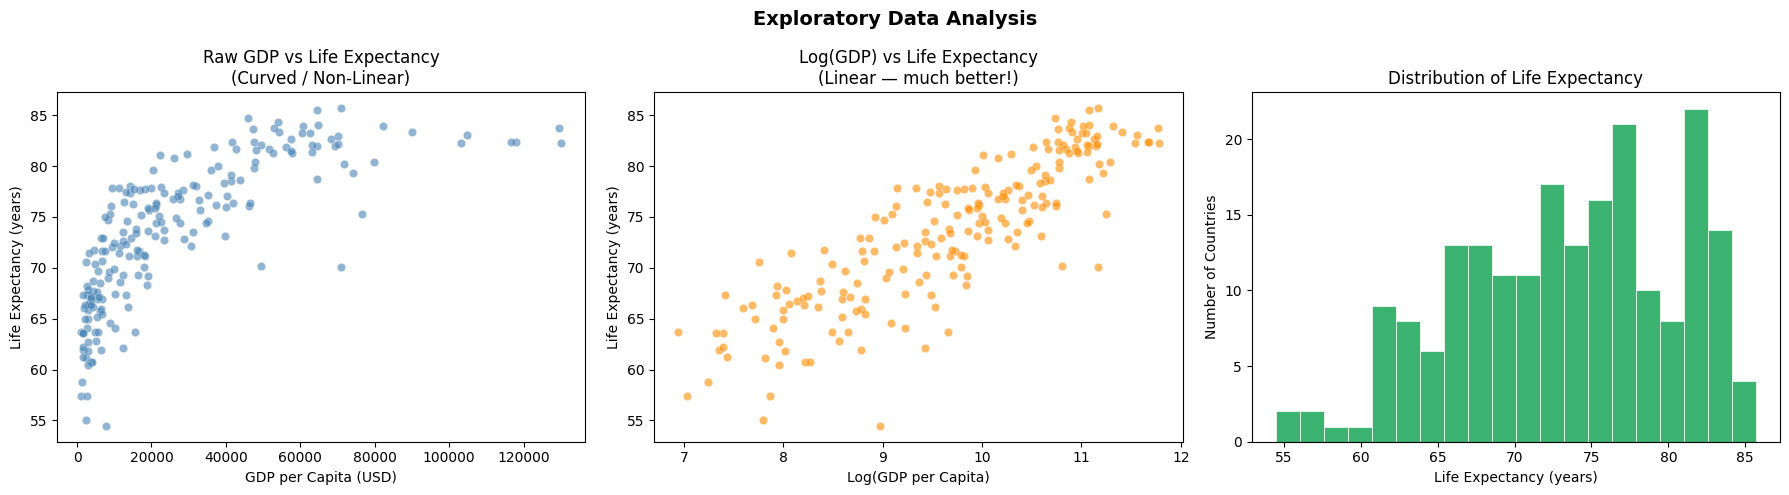

 EDA plots saved as 'eda_plots.png'

 Pearson Correlation (Log GDP vs Life Expectancy): 0.8599
   (Values close to 1 indicate strong positive linear relationship)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Plot 1: Raw GDP vs Life Expectancy (shows skew problem)
axes[0].scatter(df_year['gdp_per_capita'], df_year['life_expectancy'],
                alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.3)
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].set_title('Raw GDP vs Life Expectancy\n(Curved / Non-Linear)')

# Plot 2: Log GDP vs Life Expectancy (much more linear!)
axes[1].scatter(df_year['log_gdp_per_capita'], df_year['life_expectancy'],
                alpha=0.6, color='darkorange', edgecolors='white', linewidth=0.3)
axes[1].set_xlabel('Log(GDP per Capita)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Log(GDP) vs Life Expectancy\n(Linear — much better!)')

# Plot 3: Distribution of Life Expectancy
axes[2].hist(df_year['life_expectancy'], bins=20, color='mediumseagreen',
             edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Life Expectancy (years)')
axes[2].set_ylabel('Number of Countries')
axes[2].set_title('Distribution of Life Expectancy')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved as 'eda_plots.png'")

# Correlation check
correlation = df_year['log_gdp_per_capita'].corr(df_year['life_expectancy'])
print(f"\n Pearson Correlation (Log GDP vs Life Expectancy): {correlation:.4f}")
print("   (Values close to 1 indicate strong positive linear relationship)")

Preparing features for model training

In [ ]:
# X = Feature (input):  Log GDP per capita
# y = Target (output):  Life Expectancy

X = df_year[['log_gdp_per_capita']].values  # 2D array required by sklearn
y = df_year['life_expectancy'].values       # 1D array

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape:  {y.shape}")

# Train-Test Split
# We train on 80% of the data and evaluate on the remaining 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42      # Fixed seed for reproducibility
)
print(f"\n Train/Test Split:")
print(f"   Training samples:  {X_train.shape[0]}")
print(f"   Testing samples:   {X_test.shape[0]}")


# Standardize features to zero mean, unit variance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # Only transform test

print(f"\n  Feature scaling applied.")
print(f"   Mean (from train): {scaler.mean_[0]:.4f}")
print(f"   Std  (from train): {scaler.scale_[0]:.4f}")

Feature matrix X shape: (202, 1)
Target vector y shape:  (202,)

 Train/Test Split:
   Training samples:  161
   Testing samples:   41

  Feature scaling applied.
   Mean (from train): 9.6298
   Std  (from train): 1.1639


Training the LR Model

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


print("MODEL TRAINING COMPLETE")

print(f"\n Equation:  Life Expectancy = {model.coef_[0]:.4f} × Scaled_Log_GDP + {model.intercept_:.4f}")
print(f"\n   Intercept (β₀): {model.intercept_:.4f}")
print(f"   Coefficient (β₁): {model.coef_[0]:.4f}")
print(f"\n   Interpretation: For each 1 std deviation increase in Log(GDP),")
print(f"   life expectancy increases by ~{model.coef_[0]:.2f} years.")

MODEL TRAINING COMPLETE

 Equation:  Life Expectancy = 6.2200 × Scaled_Log_GDP + 73.3873

   Intercept (β₀): 73.3873
   Coefficient (β₁): 6.2200

   Interpretation: For each 1 std deviation increase in Log(GDP),
   life expectancy increases by ~6.22 years.


Evaluating the model

In [ ]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Compute metrics
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
train_mae  = np.mean(np.abs(y_train - y_train_pred))
test_mae   = np.mean(np.abs(y_test  - y_test_pred))


print("MODEL EVALUATION METRICS")

print(f"\n{'Metric':<30} {'Train':>10} {'Test':>10}")
print("--" * 50)
print(f"{'R² Score':<30} {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"{'RMSE (years)':<30} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"{'MAE (years)':<30} {train_mae:>10.4f} {test_mae:>10.4f}")

print(f"\n R² = {test_r2:.4f} means the model explains {test_r2*100:.1f}% of the")
print(f"   variance in life expectancy using only GDP per capita.")

MODEL EVALUATION METRICS

Metric                              Train       Test
----------------------------------------------------------------------------------------------------
R² Score                           0.7325     0.7739
RMSE (years)                       3.7590     2.9016
MAE (years)                        2.9280     2.2189

 R² = 0.7739 means the model explains 77.4% of the
   variance in life expectancy using only GDP per capita.


Visualize the results

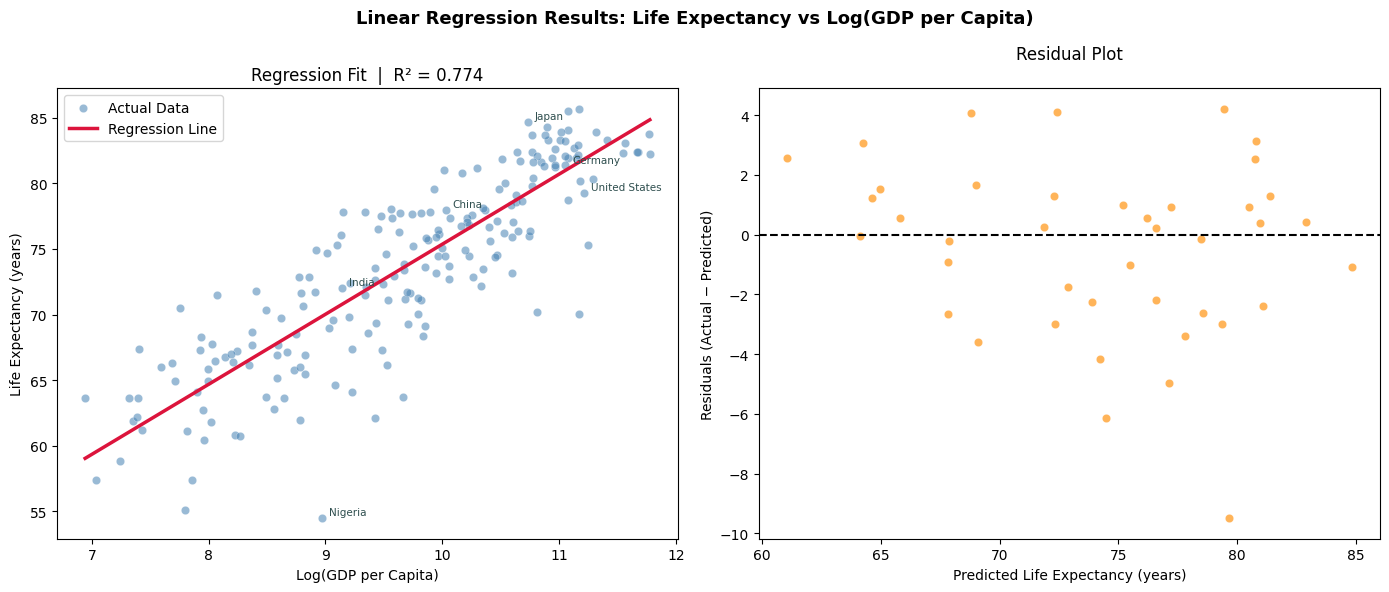

 Result plots saved as 'regression_results.png'


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression Results: Life Expectancy vs Log(GDP per Capita)',
             fontsize=13, fontweight='bold')

# Plot 1: Regression Line
X_all_scaled = scaler.transform(X)
y_all_pred = model.predict(X_all_scaled)
sort_idx = np.argsort(X.flatten())

axes[0].scatter(X, y, alpha=0.55, color='steelblue',
                edgecolors='white', linewidth=0.3, label='Actual Data', zorder=2)
axes[0].plot(X[sort_idx], y_all_pred[sort_idx],
             color='crimson', linewidth=2.5, label='Regression Line', zorder=3)

if 'country' in df_year.columns:
    highlight = ['United States', 'India', 'China', 'Germany', 'Nigeria', 'Japan']
    for _, row in df_year.iterrows():
        if row['country'] in highlight:
            axes[0].annotate(row['country'],
                             xy=(row['log_gdp_per_capita'], row['life_expectancy']),
                             fontsize=7.5, ha='left',
                             xytext=(5, 2), textcoords='offset points',
                             color='darkslategray')

axes[0].set_xlabel('Log(GDP per Capita)')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].set_title(f'Regression Fit  |  R² = {test_r2:.3f}')
axes[0].legend()

#  Plot 2: Residuals
residuals = y_test - y_test_pred

axes[1].scatter(y_test_pred, residuals, alpha=0.65,
                color='darkorange', edgecolors='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')

axes[1].set_xlabel('Predicted Life Expectancy (years)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residual Plot\n')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Result plots saved as 'regression_results.png'")

Predict for new input values

In [ ]:
print("MAKING PREDICTIONS FOR NEW GDP VALUES")

# Example GDP values to predict life expectancy for
example_gdp_values = [10000, 30000, 500000, 70000]

print(f"\n{'GDP per Capita (USD)':>22} | {'Log(GDP)':>10} | {'Predicted Life Expectancy':>26}")
print("--" * 65)

for gdp in example_gdp_values:
    log_gdp = np.log(gdp)
    log_gdp_scaled = scaler.transform([[log_gdp]])
    predicted_le = model.predict(log_gdp_scaled)[0]
    print(f"  ${gdp:>20,} | {log_gdp:>10.4f} | {predicted_le:>22.2f} years")

print("\n Prediction complete.")
print("\nNote: Predictions outside the training range are extrapolations")
print("and should be interpreted with caution.")

MAKING PREDICTIONS FOR NEW GDP VALUES

  GDP per Capita (USD) |   Log(GDP) |  Predicted Life Expectancy
----------------------------------------------------------------------------------------------------------------------------------
  $              10,000 |     9.2103 |                  71.15 years
  $              30,000 |    10.3090 |                  77.02 years
  $             500,000 |    13.1224 |                  92.05 years
  $              70,000 |    11.1563 |                  81.55 years

 Prediction complete.

Note: Predictions outside the training range are extrapolations
and should be interpreted with caution.
